# APTOS 2019 Blindness Detection - Data Cleaning & Data Split

**Purpose:** This notebook performs two critical pipeline steps:
1. **Data Cleaning** — Verify image integrity, identify and handle corrupt/problematic images
2. **Data Split** — Create stratified train/validation splits with reproducibility and leakage prevention

**Why these steps matter:**
- Corrupt or unreadable images will cause training failures or silently degrade model performance
- A proper stratified split ensures each class is proportionally represented in both sets
- Splitting BEFORE any preprocessing prevents data leakage (validation data must remain unseen during training decisions)

## 1.0 Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import cv2 #for reading and validating image files
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 77 #ensures that every run produce identical results 
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2.0 Define Paths & Load Data

In [2]:
# Define project paths
BASE_DIR = r'C:\Users\Owent\Desktop\ODL_Official_assignment\dataScience_workflow'
RAW_DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
TRAIN_IMAGES_DIR = os.path.join(RAW_DATA_DIR, 'train_images')
TEST_IMAGES_DIR = os.path.join(RAW_DATA_DIR, 'test_images')

# Create processed data directory if it doesn't exist
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Load CSV files
df_train = pd.read_csv(os.path.join(RAW_DATA_DIR, 'train.csv'))
df_test = pd.read_csv(os.path.join(RAW_DATA_DIR, 'test.csv'))

# Add full file paths
df_train['file_path'] = df_train['id_code'].apply(
    lambda x: os.path.join(TRAIN_IMAGES_DIR, f'{x}.png')
)
df_test['file_path'] = df_test['id_code'].apply(
    lambda x: os.path.join(TEST_IMAGES_DIR, f'{x}.png')
)

print(f'Training samples: {len(df_train)}')
print(f'Test samples: {len(df_test)}')
df_train.head()

Training samples: 3662
Test samples: 1928


,id_code,diagnosis,file_path
0,000c1434d8d7,2,C:\Users\Owent\Desktop\ODL_Official_assignment...
1,001639a390f0,4,C:\Users\Owent\Desktop\ODL_Official_assignment...
2,0024cdab0c1e,1,C:\Users\Owent\Desktop\ODL_Official_assignment...
3,002c21358ce6,0,C:\Users\Owent\Desktop\ODL_Official_assignment...
4,005b95c28852,0,C:\Users\Owent\Desktop\ODL_Official_assignment...


---
## 3.0 Data Cleaning

Data cleaning for image datasets involves:
1. Checking that all referenced images actually exist on disk
2. Verifying images are not corrupt (can be loaded by OpenCV)
3. Identifying problematic images (completely black, extremely dark, or blank)
4. Checking for duplicate entries in the metadata

### 3.1 Check for Missing & Duplicate Entries

In [3]:
# Check for null values in metadata
print('=== Missing Values ===')
print(f'Train set:\n{df_train.isnull().sum()}')
print(f'\nTest set:\n{df_test.isnull().sum()}')

# Check for duplicate id_codes
train_duplicates = df_train['id_code'].duplicated().sum()
test_duplicates = df_test['id_code'].duplicated().sum()

print(f'\n=== Duplicate Entries ===')
print(f'Duplicate id_codes in train: {train_duplicates}')
print(f'Duplicate id_codes in test: {test_duplicates}')

if train_duplicates == 0 and test_duplicates == 0:
    print('\n✅ No duplicates found. Metadata is clean.')
else:
    print('\n⚠️ Duplicates detected! Removing...')
    df_train = df_train.drop_duplicates(subset='id_code', keep='first').reset_index(drop=True)
    df_test = df_test.drop_duplicates(subset='id_code', keep='first').reset_index(drop=True)

=== Missing Values ===
Train set:
id_code      0
diagnosis    0
file_path    0
dtype: int64

Test set:
id_code      0
file_path    0
dtype: int64

=== Duplicate Entries ===
Duplicate id_codes in train: 0
Duplicate id_codes in test: 0

✅ No duplicates found. Metadata is clean.


### 3.2 Verify Image File Existence

In [4]:
# Verify all training images exist on disk
missing_train_images = []
for idx, row in df_train.iterrows():
    if not os.path.exists(row['file_path']):
        missing_train_images.append(row['id_code'])

# Verify all test images exist on disk
missing_test_images = []
for idx, row in df_test.iterrows():
    if not os.path.exists(row['file_path']):
        missing_test_images.append(row['id_code'])

print(f'Missing training images: {len(missing_train_images)}')
print(f'Missing test images: {len(missing_test_images)}')

if len(missing_train_images) == 0 and len(missing_test_images) == 0:
    print('\n✅ All image files verified on disk.')
else:
    if missing_train_images:
        print(f'\n⚠️ Missing train images: {missing_train_images[:10]}...')
        # Remove rows with missing images
        df_train = df_train[~df_train['id_code'].isin(missing_train_images)].reset_index(drop=True)
        print(f'Removed {len(missing_train_images)} entries. Remaining: {len(df_train)}')

Missing training images: 0
Missing test images: 0

✅ All image files verified on disk.


### 3.3 Check for Corrupt / Unreadable Images

In [5]:
# Attempt to load each training image and identify corrupt files
corrupt_images = []

for idx, row in tqdm(df_train.iterrows(), total=len(df_train), desc='Checking image integrity'):
    img = cv2.imread(row['file_path'])
    if img is None:
        corrupt_images.append(row['id_code'])

print(f'\nCorrupt/unreadable images: {len(corrupt_images)}')

if len(corrupt_images) == 0:
    print('✅ All training images are readable.')
else:
    print(f'⚠️ Corrupt images found: {corrupt_images}')
    # Remove corrupt images from dataframe
    df_train = df_train[~df_train['id_code'].isin(corrupt_images)].reset_index(drop=True)
    print(f'Removed {len(corrupt_images)} corrupt entries. Remaining: {len(df_train)}')

Checking image integrity:   0%|          | 0/3662 [00:00<?, ?it/s]


Corrupt/unreadable images: 0
✅ All training images are readable.


### 3.4 Identify Problematic Images (Blank / Extremely Dark)

In [6]:
# Identify images that are nearly completely black (mean intensity < 5)
# These may be blank captures or severely underexposed
DARK_THRESHOLD = 5  # mean pixel intensity below this is considered problematic

dark_images = []
image_brightness = []

for idx, row in tqdm(df_train.iterrows(), total=len(df_train), desc='Checking brightness'):
    img = cv2.imread(row['file_path'], cv2.IMREAD_GRAYSCALE)
    if img is not None:
        mean_val = img.mean()
        image_brightness.append(mean_val)
        if mean_val < DARK_THRESHOLD:
            dark_images.append({'id_code': row['id_code'], 'mean_brightness': mean_val, 'diagnosis': row['diagnosis']})

print(f'\nExtremely dark images (mean < {DARK_THRESHOLD}): {len(dark_images)}')

if dark_images:
    dark_df = pd.DataFrame(dark_images)
    print(dark_df)
    print('\nNote: These images are flagged but NOT removed. They may contain valid retinal data.')
    print('Decision: Keep them in the dataset as the model should learn to handle varied imaging conditions.')
else:
    print('✅ No extremely dark/blank images found.')

Checking brightness:   0%|          | 0/3662 [00:00<?, ?it/s]


Extremely dark images (mean < 5): 0
✅ No extremely dark/blank images found.


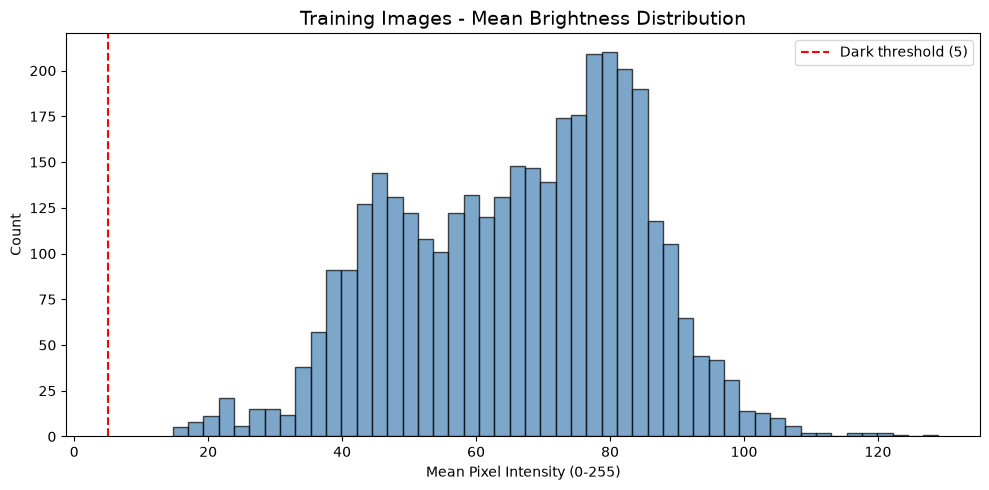

In [14]:
# Visualize brightness distribution to confirm data quality
plt.figure(figsize=(10, 5))
plt.hist(image_brightness, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=DARK_THRESHOLD, color='red', linestyle='--', label=f'Dark threshold ({DARK_THRESHOLD})')
plt.title('Training Images - Mean Brightness Distribution', fontsize=14)
plt.xlabel('Mean Pixel Intensity (0-255)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Data Cleaning Summary

In [15]:
print('='*60)
print('DATA CLEANING SUMMARY')
print('='*60)
print(f'Original training samples:    3662')
print(f'After cleaning:               {len(df_train)}')
print(f'Samples removed:              {3662 - len(df_train)}')
print(f'Missing values:               None')
print(f'Duplicate entries:            {train_duplicates}')
print(f'Missing image files:          {len(missing_train_images)}')
print(f'Corrupt images:               {len(corrupt_images)}')
print(f'Extremely dark (flagged):     {len(dark_images)} (kept in dataset)')
print('='*60)
print(f'\nFinal clean dataset size: {len(df_train)} samples')
print('Dataset is ready for splitting.')

DATA CLEANING SUMMARY
Original training samples:    3662
After cleaning:               3662
Samples removed:              0
Missing values:               None
Duplicate entries:            0
Missing image files:          0
Corrupt images:               0
Extremely dark (flagged):     0 (kept in dataset)

Final clean dataset size: 3662 samples
Dataset is ready for splitting.


---
## 4.0 Data Split (Train / Validation)

**Why split before processing?**
- Splitting FIRST ensures the validation set is truly "unseen" data
- Any preprocessing statistics (normalization mean/std) computed later will use ONLY the training portion
- This prevents **data leakage** — the #1 mistake in ML pipelines

**Split Strategy:**
- 85% Training / 15% Validation
- Stratified by `diagnosis` class to preserve class proportions
- Fixed random seed for reproducibility

### 4.1 Perform Stratified Split

In [9]:
# Stratified split: 85% train, 15% validation
# stratify=y ensures each class has proportional representation in both sets

train_df, val_df = train_test_split(
    df_train,
    test_size=0.15,
    stratify=df_train['diagnosis'],
    random_state=SEED
)

# Reset indices for clean DataFrames
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'Training set size:   {len(train_df)} ({len(train_df)/len(df_train)*100:.1f}%)')
print(f'Validation set size: {len(val_df)} ({len(val_df)/len(df_train)*100:.1f}%)')
print(f'Total:               {len(train_df) + len(val_df)}')

Training set size:   3112 (85.0%)
Validation set size: 550 (15.0%)
Total:               3662


### 4.2 Verify Class Distribution is Preserved

In [10]:
# Compare class distributions across original, train, and validation sets
class_names = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative DR'}

orig_dist = df_train['diagnosis'].value_counts(normalize=True).sort_index() * 100
train_dist = train_df['diagnosis'].value_counts(normalize=True).sort_index() * 100
val_dist = val_df['diagnosis'].value_counts(normalize=True).sort_index() * 100

dist_comparison = pd.DataFrame({
    'Class': [class_names[i] for i in range(5)],
    'Original (%)': orig_dist.values.round(2),
    'Train (%)': train_dist.values.round(2),
    'Validation (%)': val_dist.values.round(2)
})

print('Class Distribution Comparison (should be nearly identical):')
print(dist_comparison.to_string(index=False))

Class Distribution Comparison (should be nearly identical):
           Class  Original (%)  Train (%)  Validation (%)
           No DR         49.29      49.29           49.27
            Mild         10.10      10.09           10.18
        Moderate         27.28      27.28           27.27
          Severe          5.27       5.27            5.27
Proliferative DR          8.06       8.07            8.00


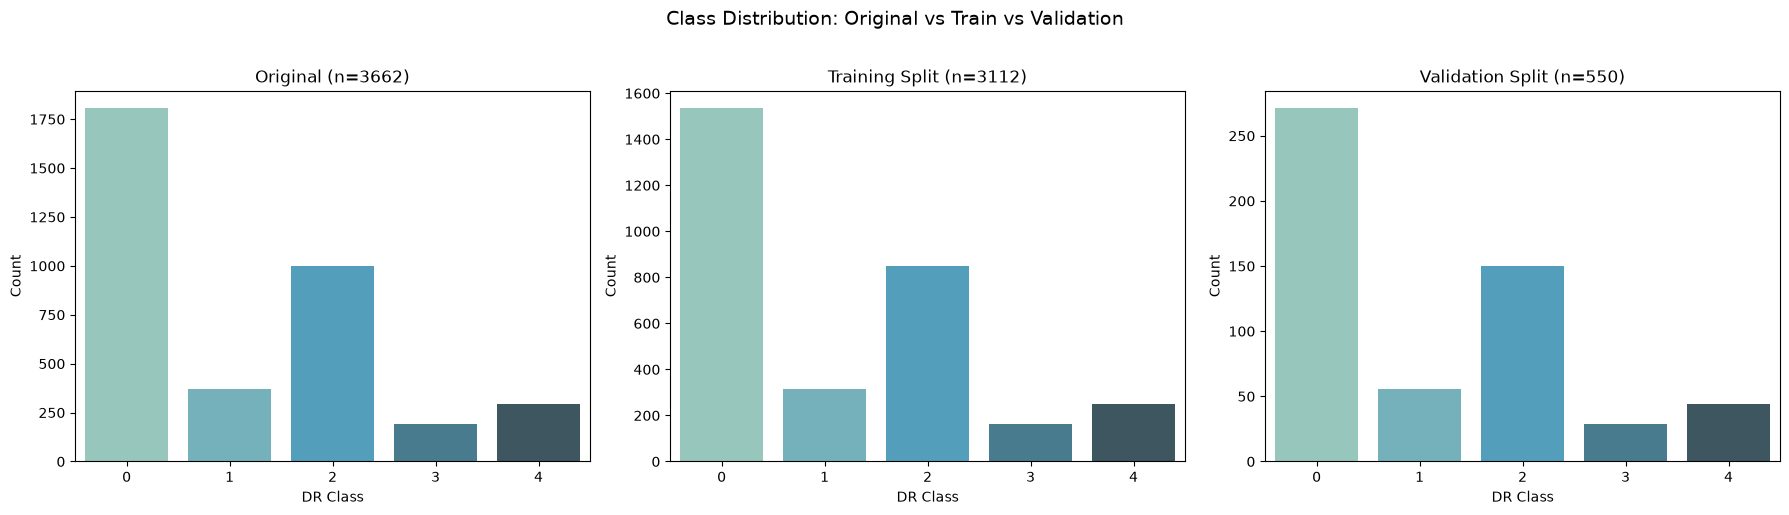


✅ Stratified split successful - class proportions are preserved in both sets.


In [11]:
# Visual comparison of class distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
sns.countplot(x='diagnosis', data=df_train, palette='GnBu_d', ax=axes[0])
axes[0].set_title(f'Original (n={len(df_train)})', fontsize=12)
axes[0].set_xlabel('DR Class')
axes[0].set_ylabel('Count')

# Train split
sns.countplot(x='diagnosis', data=train_df, palette='GnBu_d', ax=axes[1])
axes[1].set_title(f'Training Split (n={len(train_df)})', fontsize=12)
axes[1].set_xlabel('DR Class')
axes[1].set_ylabel('Count')

# Validation split
sns.countplot(x='diagnosis', data=val_df, palette='GnBu_d', ax=axes[2])
axes[2].set_title(f'Validation Split (n={len(val_df)})', fontsize=12)
axes[2].set_xlabel('DR Class')
axes[2].set_ylabel('Count')

plt.suptitle('Class Distribution: Original vs Train vs Validation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\n✅ Stratified split successful - class proportions are preserved in both sets.')

### 4.3 Data Leakage Prevention Check

In [12]:
# CRITICAL: Verify there is NO overlap between train and validation sets
# Any overlap = data leakage

train_ids = set(train_df['id_code'].values)
val_ids = set(val_df['id_code'].values)

overlap = train_ids.intersection(val_ids)

print('=== DATA LEAKAGE CHECK ===')
print(f'Training set unique IDs:   {len(train_ids)}')
print(f'Validation set unique IDs: {len(val_ids)}')
print(f'Overlapping IDs:           {len(overlap)}')

if len(overlap) == 0:
    print('\n✅ NO DATA LEAKAGE DETECTED.')
    print('   Train and validation sets are completely independent.')
    print('   No sample appears in both sets.')
else:
    print(f'\n❌ DATA LEAKAGE FOUND! {len(overlap)} samples appear in both sets!')
    print('   This must be fixed before proceeding.')

=== DATA LEAKAGE CHECK ===
Training set unique IDs:   3112
Validation set unique IDs: 550
Overlapping IDs:           0

✅ NO DATA LEAKAGE DETECTED.
   Train and validation sets are completely independent.
   No sample appears in both sets.


### 4.4 Save Split DataFrames

In [13]:
# Save the split DataFrames to CSV for use in subsequent notebooks
# This ensures reproducibility — the exact same split is used every time

train_save_path = os.path.join(PROCESSED_DATA_DIR, 'train_split.csv')
val_save_path = os.path.join(PROCESSED_DATA_DIR, 'val_split.csv')

# Save only id_code and diagnosis (file_path can be reconstructed)
train_df[['id_code', 'diagnosis']].to_csv(train_save_path, index=False)
val_df[['id_code', 'diagnosis']].to_csv(val_save_path, index=False)

print(f'Training split saved to:   {train_save_path}')
print(f'Validation split saved to: {val_save_path}')
print(f'\nThese files will be loaded in the Data Processing notebook.')
print('This guarantees the same split is used across all pipeline stages.')

Training split saved to:   C:\Users\Owent\Desktop\ODL_Official_assignment\dataScience_workflow\data\processed\train_split.csv
Validation split saved to: C:\Users\Owent\Desktop\ODL_Official_assignment\dataScience_workflow\data\processed\val_split.csv

These files will be loaded in the Data Processing notebook.
This guarantees the same split is used across all pipeline stages.


---
## 5.0 Summary

### What was accomplished:

| Step | Action | Result |
|------|--------|--------|
| 3.1 | Check missing/duplicate entries | No issues found |
| 3.2 | Verify image files exist | All files present |
| 3.3 | Check for corrupt images | All images readable |
| 3.4 | Identify dark/blank images | Flagged (kept in dataset) |
| 4.1 | Stratified train/val split | 85%/15% split done |
| 4.2 | Verify distribution preserved | ✅ Confirmed |
| 4.3 | Data leakage check | ✅ No leakage |
| 4.4 | Save splits to disk | CSVs saved |

### Data Leakage Prevention Measures:
1. Split performed on **raw data** before any preprocessing
2. Zero overlap verified between train and validation sets
3. Split files saved to disk for consistent use across all subsequent pipeline stages
4. Normalization statistics will be computed from training set ONLY in the next notebook

### Next Step:
→ `03_Data_Processing.ipynb` — Apply Ben Graham's preprocessing, resize images, and define augmentation pipeline